In [ ]:
#opcional (instala pandas seaborn matplotlib scikit-learn numpy, tarda aprox. 3.5 minutos)
%pip install -r requirements.txt

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 9.3 MB/s eta 0:00:01
   ------------- -------------------------- 3.4/9.9 MB 7.2 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 8.6 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.9 MB/s  0:00:01
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 13.2 MB/s eta 0:00:01
 

In [3]:
import pandas as pd
import holidays
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

ModuleNotFoundError: No module named 'pandas'

# EDA:

Cargamos y visualizamos el dataset.

In [2]:
df = pd.read_csv('./content/uber_fares.csv')
df
prueba = df['fare_amount']

NameError: name 'pd' is not defined

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


Corroboramos la existencia de nulos y observamos el porcentaje respecto al total para decidir que hacer con ellos.

In [82]:
df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / df.shape[0]) * 100
porcentaje_nulos

key                  0.0000
date                 0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
dtype: float64

Dado que los nulos encontrados en las variables "dropoff_longitude" y "dropoff_latitude" equivalen a un 0.0005% de los datos del dataset, decidimos eliminar sus filas correspondientes para simplificar el preprocesamiento sin afectar el análisis.

In [83]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                199999 non-null  int64  
 1   date               199999 non-null  str    
 2   fare_amount        199999 non-null  float64
 3   pickup_datetime    199999 non-null  str    
 4   pickup_longitude   199999 non-null  float64
 5   pickup_latitude    199999 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    199999 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 15.3 MB


También detectamos que tanto la variable "pickup_datetime" y "date" son de tipo Object, para una mejor manipulacion de datos las transformamos en tipo datetime.

In [84]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199999 non-null  int64              
 1   date               199999 non-null  datetime64[us]     
 2   fare_amount        199999 non-null  float64            
 3   pickup_datetime    199999 non-null  datetime64[us, UTC]
 4   pickup_longitude   199999 non-null  float64            
 5   pickup_latitude    199999 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    199999 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 15.3 MB


Observamos que lo único en lo que difieren los datos de la columna "pickup_datetime" y "date" es en que una muestra la zona horaria. Fuera de eso "date" seria redundante por lo que vamos a comprobar si todas las fechas son iguales y en caso de serlo podriamos eliminar la columna "date".

In [85]:
(df['date'].dt.date == df['pickup_datetime'].dt.date).value_counts()

True    199999
Name: count, dtype: int64

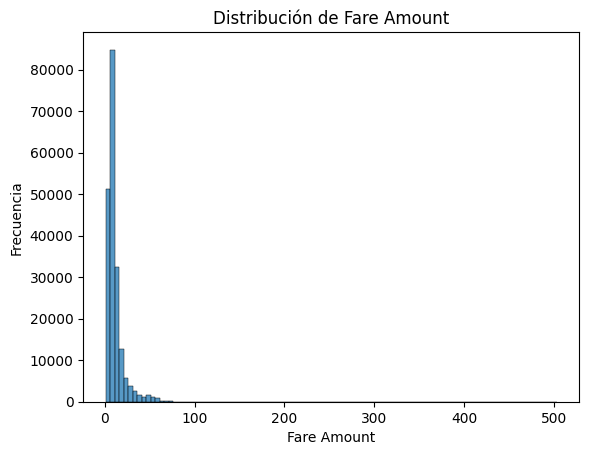

In [86]:
#visualizacion de fare_amount (capaz convenga visualizar otras variables)
sns.histplot(df['fare_amount'], bins=100)
plt.title('Distribución de Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Frecuencia')
plt.show()

Notamos que hay valores atípicos en las tarifas, como 0 o valores exageradamente altos, por lo que conviene eliminarlos 

In [88]:
#Creo que no hay pero no se si se rompio el VS de ultima lo elimino 
eliminados = df[df['fare_amount'] <= 0]
df = df[df['fare_amount'] > 0]
print(len(eliminados))

0


In [89]:
y = df['fare_amount']

In [50]:
#eliminamos los valores atípicos
# Usámos el método de los cuartiles, marcamos como outliers los valores superiores a Q3 + 1,5 × RI o inferiores a Q1 - 1,5 × RI

len1 = len(df)
Q1 = y.quantile(0.25) # cuantil 0.25 (busca el valor donde la probabilidad acumulada es del 25%)
Q3 = y.quantile(0.75) # cuantil 0.75 ('' el 75% de las tarifas son menores a este valor)
RI = Q3 - Q1       # rango intercuartílico

limite_inf = Q1 - 1.5 * RI 
limite_sup = Q3 + 1.5 * RI

#corta por encima y por debajo de los límites
df = df[(y >= limite_inf) & (y <= limite_sup)]
df.info()
len2 = len(df)
print(len1 - len2)

<class 'pandas.DataFrame'>
Index: 183350 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                183350 non-null  int64              
 1   date               183350 non-null  datetime64[us]     
 2   fare_amount        183350 non-null  float64            
 3   pickup_datetime    183350 non-null  datetime64[us, UTC]
 4   pickup_longitude   183350 non-null  float64            
 5   pickup_latitude    183350 non-null  float64            
 6   dropoff_longitude  183350 non-null  float64            
 7   dropoff_latitude   183350 non-null  float64            
 8   passenger_count    183350 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 14.0 MB
16649


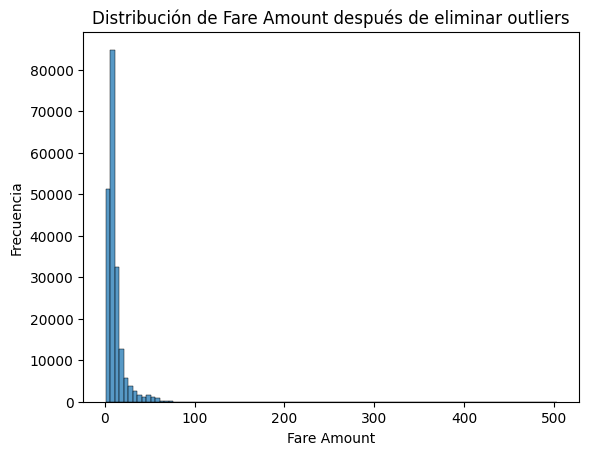

In [90]:
#visualizacion de fare_amount luego de eliminar outliers
sns.histplot(df['fare_amount'], bins=100)
plt.title('Distribución de Fare Amount después de eliminar outliers')
plt.xlabel('Fare Amount')
plt.ylabel('Frecuencia')
plt.show()

Vemos que ahora no aparecen valores atípicos y que los precios de las tarifas son razonables, aproximadamente entre 2.5 y 17.5 (asumo que las tarifas están en dólares)

In [91]:
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='str')

In [92]:
x=df[['key', 'date', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count']]

Ubicaciones:

In [93]:
#Centro aprox de Nueva York 
centro = [40.7128, -74.0060]

m = folium.Map(location=centro, zoom_start=11)

sample_df = df.sample(2000, random_state=42)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row["pickup_latitude"], row["pickup_longitude"]],
        radius=1,
        color="blue",
        fill=True,
        fill_opacity=0.5
    ).add_to(m)

    folium.CircleMarker(
        location=[row["dropoff_latitude"], row["dropoff_longitude"]],
        radius=1,
        color="red",
        fill=True,
        fill_opacity=0.5
    ).add_to(m)


# Círculo de 50 km
folium.Circle(
    location=centro,
    radius=50000,  # metros
    color="green",
    fill=True,
    fill_opacity=0.08,
    popup="Radio de 50 km"
).add_to(m)

# Círculo de 100 km
folium.Circle(
    location=centro,
    radius=100000,  # metros
    color="orange",
    fill=True,
    fill_opacity=0.05,
    popup="Radio 100 Km"
).add_to(m)

La mayoria de los puntos tanto de Inicio como de destino se encuentran en Nueva York y alrededores, algunos estan en puntos muy alejados, si bien los viajes a otros estados dentro de USA podrian ser posibles parecen poco probables sobre todo tomando en cuenta el rango de las tarifas por lo que los puntos muy alejados los vamos a sacar y despeus imputaremos su distancia utilizando algun metodo con los puntos restantes.

Vemos aca que la mayoria de lo viajes empiezan y terminan en un radio menor a 50km respecto al centro de Nueva York por lo que vamos a considerar al resto de puntos como errores siendo que no es comun tomar viajes de uber tan largos y algunos tienen puntos en lugares sin sentido como en el oceano. El modelo se vera limitado a no poder predecir correctamente para viajes mayores a 50Km pero no es un caso comun.

In [94]:
m

In [95]:
def es_nuevayork(lat, lon):
    """
    Valida si una coordenada está dentro de los límites de NYC mas
    un radio de 50 km para viajes por fuera.
    """
    return (40.2 <= lat <= 41.2) and (-74.6 <= lon <= -73.4)


# Aplico es_coord True: Dentro NYC False:Fuera NYC (Valido Lat, Long)
df["pickup_en_ny"] = df.apply(lambda row: es_nuevayork(row["pickup_latitude"], row["pickup_longitude"]), axis=1)
df["dropoff_en_ny"] = df.apply(lambda row: es_nuevayork(row["dropoff_latitude"], row["dropoff_longitude"]), axis=1)

#  Valido punto de partida y llegada dentro de la zona definida.
df["viaje_en_ny"] = df["pickup_en_ny"] & df["dropoff_en_ny"]
df.describe()
df['viaje_en_ny'].value_counts()

viaje_en_ny
True     195704
False      4295
Name: count, dtype: int64

Hay aproximadamente 4000 viajes cuyo inicio o final no estan dentro del radio aproximado de 50Km respecto al centro de Manhattan 

In [97]:
df["pickup_en_ny"].value_counts()

pickup_en_ny
True     195927
False      4072
Name: count, dtype: int64

In [ ]:
df["dropoff_en_ny"].value_counts()

dropoff_en_ny
True     195959
False      4040
Name: count, dtype: int64

In [ ]:
#Reemplamos las coordenadas fuera de zona por valores NULOS para luego imputarlos con algun método.
df.loc[~df["pickup_en_ny"], ["pickup_latitude", "pickup_longitude"]] = np.nan
df.loc[~df["dropoff_en_ny"], ["dropoff_latitude", "dropoff_longitude"]] = np.nan

In [102]:
df['dropoff_en_ny'].value_counts()

dropoff_en_ny
True     195959
False      4040
Name: count, dtype: int64

In [101]:

nulos_por_columna = df.isnull().sum()

print(nulos_por_columna)

key                     0
date                    0
fare_amount             0
pickup_datetime         0
pickup_longitude     4072
pickup_latitude      4072
dropoff_longitude    4040
dropoff_latitude     4040
passenger_count         0
pickup_en_ny            0
dropoff_en_ny           0
viaje_en_ny             0
dtype: int64


In [103]:
df.shape

(199999, 12)

In [139]:
df2 = df.copy()

In [140]:
df2["passenger_count"].value_counts()

passenger_count
1      138425
2       29428
5       14009
3        8881
4        4276
6        4271
0         708
208         1
Name: count, dtype: int64

In [141]:
# Uber Envio (0 pasajeros) y UberXL para viajes de grupos de hasta 5 o 6 personas.
#Por lo que el valor atipico en cantidad de pasajeros seria el de 208 lo vamos a tomar como el maximo valor posible (podriamos eliminarlo ya que es 1 solo)
df2.loc[(df2['passenger_count'] > 6) , 'passenger_count'] = 6
df2["passenger_count"].value_counts()

passenger_count
1    138425
2     29428
5     14009
3      8881
4      4276
6      4272
0       708
Name: count, dtype: int64

In [142]:
def categoria_uber(df_uber):
    condiciones = [
        df_uber["passenger_count"] == 0,
        df_uber["passenger_count"].between(1, 4),
        df_uber["passenger_count"].between(5, 6)
    ]

    valores = ["Uber Envio", "Uber X", "Uber XL"]

    df_uber["categoria_uber"] = np.select(condiciones, valores, default="Error")
    return df_uber

In [143]:
df2 = categoria_uber(df2)

In [144]:
df2["categoria_uber"].value_counts()

categoria_uber
Uber X        181010
Uber XL        18281
Uber Envio       708
Name: count, dtype: int64

In [ ]:
#Extraemos el dia de la semana Monday = 0 Sunday = 6 (documentacion pandas)
df2['date'] = pd.to_datetime(df2['date'])
df2['dia_de_la_semana'] = df2['date'].dt.weekday
df2['dia_de_la_semana'].value_counts()

dia_de_la_semana
4    30884
5    30247
3    30031
2    29032
1    28114
6    26436
0    25255
Name: count, dtype: int64

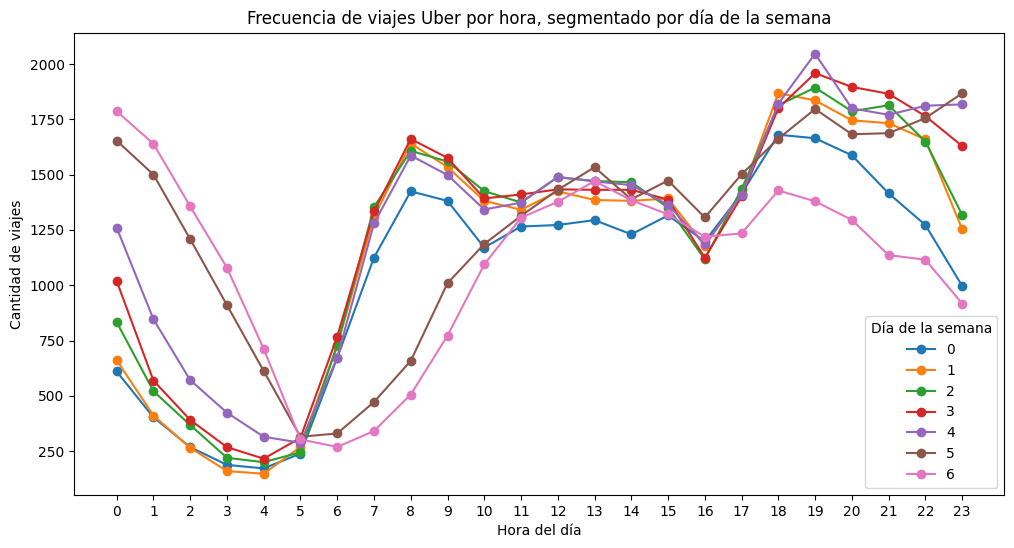

In [147]:
df2["hour"] = pd.to_datetime(df2["pickup_datetime"]).dt.hour

conteo = df2.groupby(["dia_de_la_semana", "hour"]).size().reset_index(name="viajes")


plt.figure(figsize=(12,6))
for dia in conteo["dia_de_la_semana"].unique():
    subset = conteo[conteo["dia_de_la_semana"] == dia]
    plt.plot(subset["hour"], subset["viajes"], marker="o", label=dia)

plt.xlabel("Hora del día")
plt.ylabel("Cantidad de viajes")
plt.title("Frecuencia de viajes Uber por hora, segmentado por día de la semana")
plt.xticks(range(24))
plt.legend(title="Día de la semana")
plt.show()

In [148]:
df2['pickup_datetime'] = df2['date'].dt.hour
df2
def franja(hora):
  if(0 <= hora <6):
    return 'Madrugada'
  elif(6<= hora <12):
    return 'Mañana'
  elif(12<= hora <18):
    return 'Tarde'
  elif(18<= hora <= 23):
    return 'Noche'

df2['franja_horaria'] = df2['pickup_datetime'].apply(franja)
df2['franja_horaria'].value_counts()

franja_horaria
Noche        68673
Tarde        57434
Mañana       48161
Madrugada    25731
Name: count, dtype: int64

In [ ]:
us_holidays = holidays.US(years=df2["date"].dt.year.unique())
df2["Feriado"] = df2["date"].dt.date.isin(us_holidays)
df2["Feriado"].value_counts()

Feriado
False    195472
True       4527
Name: count, dtype: int64

In [152]:
#Por logica pensamos que a fin de mes la gente podria tomar menos uber por lo que por la menor demanda podrian ser mas baratos los viajes
def semana_del_mes(dt):
    dia = dt.day
    if 1 <= dia <= 7:
        return 1
    elif 8 <= dia <= 15:
        return 2
    elif 16 <= dia <= 23:
        return 3
    else:
        return 4

df2["week_of_month"] = df2["date"].apply(semana_del_mes)
df2["week_of_month"] .value_counts()


week_of_month
3    54168
2    53907
4    47157
1    44767
Name: count, dtype: int64

In [ ]:
def division_distritos_NY(lat, lon):
    # Diccionario con rangos aproximados de cada distrito (lat_min, lat_max, lon_min, lon_max)
    barrios = {
        "Manhattan":   (40.7000, 40.8800, -74.0200, -73.9300),
        "Brooklyn":    (40.5700, 40.7400, -74.0500, -73.8500),
        "Queens":      (40.5400, 40.8000, -73.9600, -73.7000),
        "Bronx":       (40.7900, 40.9200, -73.9300, -73.7600),
        "Staten Island": (40.4800, 40.6500, -74.2500, -74.0500),
    }

    for barrio, (lat_min, lat_max, lon_min, lon_max) in barrios.items():
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return barrio
    return "Fuera de NYC"
df2["barrio"] = df2.apply(
    lambda row: division_distritos_NY(row["pickup_latitude"], row["pickup_longitude"]),
    axis=1
)
# Verificar resultado
print(df2[["pickup_latitude", "pickup_longitude", "barrio"]].head(30))
df2['barrio'].value_counts()

    pickup_latitude  pickup_longitude        barrio
0         40.738354        -73.999817     Manhattan
1         40.728225        -73.994355     Manhattan
2         40.740770        -74.005043     Manhattan
3         40.790844        -73.976124     Manhattan
4         40.744085        -73.925023        Queens
5         40.755910        -73.969019     Manhattan
6         40.693965        -73.961447      Brooklyn
7               NaN               NaN  Fuera de NYC
8         40.745767        -73.975187     Manhattan
9         40.741787        -74.001065     Manhattan
10        40.746952        -73.974388     Manhattan
11              NaN               NaN  Fuera de NYC
12        40.804440        -73.966378     Manhattan
13        40.767382        -73.953352     Manhattan
14        40.755193        -73.973370     Manhattan
15        40.751920        -73.990718     Manhattan
16        40.756982        -73.988908     Manhattan
17        40.741138        -74.005665     Manhattan
18        40

barrio
Manhattan        183828
Queens             8744
Fuera de NYC       4317
Brooklyn           2879
Bronx               217
Staten Island        14
Name: count, dtype: int64

Calculo de Distancia segun coordenadas (Colab hecho en clase)

In [153]:
df2.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   key                199999 non-null  int64         
 1   date               199999 non-null  datetime64[us]
 2   fare_amount        199999 non-null  float64       
 3   pickup_datetime    199999 non-null  int32         
 4   pickup_longitude   195927 non-null  float64       
 5   pickup_latitude    195927 non-null  float64       
 6   dropoff_longitude  195959 non-null  float64       
 7   dropoff_latitude   195959 non-null  float64       
 8   passenger_count    199999 non-null  int64         
 9   pickup_en_ny       199999 non-null  bool          
 10  dropoff_en_ny      199999 non-null  bool          
 11  viaje_en_ny        199999 non-null  bool          
 12  categoria_uber     199999 non-null  str           
 13  dia_de_la_semana   199999 non-null  int32         
 14  hour

Encoding e Imputaciones